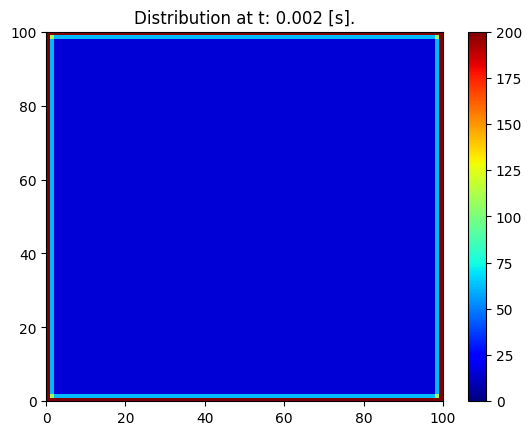

KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# Definere objektet

a = 127 # termisk diffusivitet [mm^2/s]
length = 99 # mm
time = 4 # sekunder

# diskretisering 

nodes = 100 # punkter
dx = length / (nodes-1) 
dy = length / (nodes-1)

# stabilitetskravet (CFL-betingelsen) for en eksplisitt numerisk løsning
dt = min(dx**2 / (4 * a),     dy**2 / (4 * a))


# Initial- og randbetingelser

u = np.zeros((nodes, nodes)) + 15 # Starttemperaturen er 15 grader

u[0, :] = 200 # temperatur bunn
u[-1, :] = 200 # temperatur topp

u[:, 0] = 200 # temperatur venstre
u[:, -1] = 200 # temperatur høyre

# Visualisering med varmeplot

fig, axis = plt.subplots()

pcm = axis.pcolormesh(u, cmap=plt.cm.jet, vmin=0, vmax=200)
plt.colorbar(pcm, ax=axis)

# Simulering

counter = 0
u_midt = [15]
tid = [0]

while u[50, 50] <= 130 :

    w = u.copy()

    for i in range(1, nodes - 1):
        for j in range(1, nodes - 1):

            dd_ux = (w[i-1, j] - 2*w[i, j] + w[i+1, j])/dx**2 # Andrederiverte av u med hensyn på x
            dd_uy = (w[i, j-1] - 2*w[i, j] + w[i, j+1])/dy**2 # Andrederiverte av u med hensyn på y

            u[i, j] = dt * a * (dd_ux + dd_uy) + w[i, j] #Forover Euler

    counter += dt

    u_midt.append(u[50, 50])
    tid.append(counter)

    #print(f"midtpunktet er {u[50, 50]:.3f} [C] ved {counter:.3f}[s]")


    # Oppdatere plottet

    pcm.set_array(u)
    axis.set_title("Distribution at t: {:.3f} [s].".format(counter))
    plt.pause(0.01)


plt.show()

plt.figure()  # Lager ny figur

plt.plot(tid, u_midt)

plt.xlabel("Tid (s)")
plt.ylabel("Temperatur (°C)")
plt.title("Temperatur i midtpunktet som funksjon av tid")

plt.grid()
plt.show()